# First Extract Imbalance price Using API

In [37]:
%pip install prophet
%pip install pmdarima
%pip install hmmlearn
%pip install catboost
import prophet
from prophet import Prophet
print(prophet.__version__)

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
1.3.0


#### ============================
####  PREDICT 5 QUARTERS AHEAD
#### ============================

In [ ]:
# ============================================
# STEP 1: TRAIN THE 5-FUTURE PRICE MODEL
# Run this cell first (takes 15-30 minutes)
# ============================================

import requests
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, VotingRegressor
from sklearn.calibration import CalibratedClassifierCV

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

np.random.seed(42)

# ============================================
# DATA EXTRACTION
# ============================================

def fetch_training_data(price_area='DK1', start_date='2025-05-01'):
    """
    Fetch data from May 1, 2025 to today
    """
    print(f"📊 Fetching data from {start_date} to today for {price_area}...")
    
    end_date = datetime.now().strftime('%Y-%m-%d')
    
    url = "https://api.energidataservice.dk/dataset/ImbalancePrice"
    
    params = {
        'limit': 100000,
        'timezone': 'Europe/Copenhagen',
        'sort': 'TimeUTC ASC',
        'start': start_date,
        'end': end_date,
        'PriceArea': price_area
    }
    
    try:
        response = requests.get(url, params=params, timeout=60)
        response.raise_for_status()
        data = response.json()
        
        df = pd.DataFrame(data['records'])
        
        # Convert time columns
        if 'TimeUTC' in df.columns:
            df['TimeUTC'] = pd.to_datetime(df['TimeUTC'])
        if 'TimeDK' in df.columns:
            df['TimeDK'] = pd.to_datetime(df['TimeDK'])
        
        df = df.sort_values('TimeUTC')
        
        print(f"✅ Fetched {len(df)} records")
        print(f"📅 Period: {df['TimeUTC'].min()} to {df['TimeUTC'].max()}")
        print(f"📍 Price Areas: {df['PriceArea'].unique()}")
        
        return df
        
    except Exception as e:
        print(f"❌ Error fetching data: {e}")
        return None

# ============================================
# FEATURE ENGINEERING
# ============================================

class MultiStepDataPreprocessor:
    """
    Preprocessor that creates features and targets for 5 future prices
    Each target is 15 minutes apart: 15, 30, 45, 60, 75 minutes ahead
    """
    
    def __init__(self):
        self.scaler = StandardScaler()
        self.feature_names = []
        self.fixed_feature_columns = None
        self.n_predictions = 5
        
    def create_features(self, df, is_training=True):
        df_copy = df.copy()
        
        # 23 Columns renaming
        rename_map = {
            'TimeUTC': 'timestamp', 'TimeDK': 'time_dk', 'PriceArea': 'price_area',
            'Satisfied Demand (MW)': 'satisfied_demand', 'SatisfiedDemand': 'satisfied_demand',
            'Imbalance Price (EUR)': 'imbalance_price_eur', 'ImbalancePriceEUR': 'imbalance_price_eur',
            'Spot Price (EUR)': 'spot_price_eur', 'SpotPriceEUR': 'spot_price_eur',
            'Dominating Direction': 'dominating_direction', 'DominatingDirection': 'dominating_direction',
            'aFRR Up (MWh)': 'afrr_up_mwh', 'aFRRUpMW': 'afrr_up_mwh',
            'aFRR VWA Up (EUR)': 'afrr_vwa_up_eur', 'aFRRVWAUpEUR': 'afrr_vwa_up_eur',
            'aFRR Down (MWh)': 'afrr_down_mwh', 'aFRRDownMW': 'afrr_down_mwh',
            'aFRR VWA Down (EUR)': 'afrr_vwa_down_eur', 'aFRRVWADownEUR': 'afrr_vwa_down_eur',
            'mFRR Marginal Price Up (EUR)': 'mfrr_up_eur', 'mFRRMarginalPriceUpEUR': 'mfrr_up_eur',
            'mFRR Marginal Price Down (EUR)': 'mfrr_down_eur', 'mFRRMarginalPriceDownEUR': 'mfrr_down_eur'
        }
        
        for old, new in rename_map.items():
            if old in df_copy.columns:
                df_copy[new] = df_copy[old]
        
        # Data type conversion
        numeric_cols = [
            'satisfied_demand', 'imbalance_price_eur', 'imbalance_price_dkk',
            'spot_price_eur', 'dominating_direction',
            'afrr_up_mwh', 'afrr_vwa_up_eur',
            'afrr_down_mwh', 'afrr_vwa_down_eur',
            'mfrr_up_eur', 'mfrr_down_eur'
        ]
        
        for col in numeric_cols:
            if col in df_copy.columns:
                df_copy[col] = pd.to_numeric(df_copy[col], errors='coerce').fillna(0)
        
        # Time features
        if 'timestamp' in df_copy.columns:
            df_copy['timestamp'] = pd.to_datetime(df_copy['timestamp'])
            df_copy['hour'] = df_copy['timestamp'].dt.hour.astype(float)
            df_copy['day_of_week'] = df_copy['timestamp'].dt.dayofweek.astype(float)
            df_copy['month'] = df_copy['timestamp'].dt.month.astype(float)
            df_copy['quarter'] = df_copy['timestamp'].dt.quarter.astype(float)
            df_copy['is_weekend'] = df_copy['day_of_week'].isin([5, 6]).astype(float)
            df_copy['is_peak'] = df_copy['hour'].isin([7, 8, 9, 16, 17, 18, 19]).astype(float)
            df_copy['sin_hour'] = np.sin(2 * np.pi * df_copy['hour'] / 24)
            df_copy['cos_hour'] = np.cos(2 * np.pi * df_copy['hour'] / 24)
            
            # Market rule change
            rule_change_date = pd.Timestamp('2026-03-04')
            df_copy['is_new_market_rule'] = (df_copy['timestamp'] >= rule_change_date).astype(float)
        
        # Market Structure Features
        if 'afrr_vwa_up_eur' in df_copy.columns and 'afrr_vwa_down_eur' in df_copy.columns:
            df_copy['afrr_price_spread'] = (df_copy['afrr_vwa_up_eur'] - df_copy['afrr_vwa_down_eur']).astype(float)
            df_copy['afrr_price_ratio'] = (df_copy['afrr_vwa_up_eur'] / (df_copy['afrr_vwa_down_eur'] + 1e-6)).astype(float)
        
        if 'afrr_up_mwh' in df_copy.columns and 'afrr_down_mwh' in df_copy.columns:
            df_copy['afrr_net_volume'] = (df_copy['afrr_up_mwh'] - df_copy['afrr_down_mwh']).astype(float)
            df_copy['afrr_total_volume'] = (df_copy['afrr_up_mwh'] + df_copy['afrr_down_mwh']).astype(float)
        
        if 'mfrr_up_eur' in df_copy.columns and 'mfrr_down_eur' in df_copy.columns:
            df_copy['mfrr_price_spread'] = (df_copy['mfrr_up_eur'] - df_copy['mfrr_down_eur']).astype(float)
            df_copy['mfrr_activated'] = ((df_copy['mfrr_up_eur'] > 0) | (df_copy['mfrr_down_eur'] > 0)).astype(float)
        
        if 'imbalance_price_eur' in df_copy.columns and 'spot_price_eur' in df_copy.columns:
            df_copy['price_spread'] = (df_copy['imbalance_price_eur'] - df_copy['spot_price_eur']).astype(float)
            df_copy['price_ratio'] = (df_copy['imbalance_price_eur'] / (df_copy['spot_price_eur'] + 1e-6)).astype(float)
            df_copy['price_deviation_pct'] = (df_copy['price_spread'] / (df_copy['spot_price_eur'] + 1e-6) * 100).astype(float)
        
        if 'dominating_direction' in df_copy.columns:
            df_copy['direction_up'] = (df_copy['dominating_direction'] == 1).astype(float)
            df_copy['direction_down'] = (df_copy['dominating_direction'] == -1).astype(float)
            df_copy['direction_neutral'] = (df_copy['dominating_direction'] == 0).astype(float)
        
        # Lag Features
        lag_features = ['imbalance_price_eur', 'spot_price_eur', 'satisfied_demand']
        for lag in [1, 2, 3, 4, 5, 6, 8, 10, 12, 16, 20, 24, 30, 36, 48]:
            for feat in lag_features:
                if feat in df_copy.columns and 'price_area' in df_copy.columns:
                    df_copy[f'lag_{lag}_{feat}'] = df_copy.groupby('price_area')[feat].shift(lag).fillna(0).astype(float)
        
        # Rolling Statistics
        if 'imbalance_price_eur' in df_copy.columns and 'price_area' in df_copy.columns:
            for window in [3, 4, 5, 6, 8, 10, 12, 16, 20, 24, 30, 36, 48]:
                df_copy[f'roll_mean_{window}'] = df_copy.groupby('price_area')['imbalance_price_eur'].transform(
                    lambda x: x.rolling(window=window, min_periods=1).mean()
                ).fillna(0).astype(float)
                df_copy[f'roll_std_{window}'] = df_copy.groupby('price_area')['imbalance_price_eur'].transform(
                    lambda x: x.rolling(window=window, min_periods=1).std()
                ).fillna(0).astype(float)
        
        # Fill missing values
        df_copy = df_copy.fillna(0)
        
        # Drop non-numeric columns
        cols_to_drop = ['timestamp', 'time_dk', 'TimeUTC', 'TimeDK']
        for col in cols_to_drop:
            if col in df_copy.columns:
                df_copy = df_copy.drop(columns=[col])
        
        # Get numeric columns
        numeric_cols = df_copy.select_dtypes(include=[np.number]).columns.tolist()
        
        # Remove target
        if 'imbalance_price_eur' in numeric_cols:
            numeric_cols.remove('imbalance_price_eur')
        
        if is_training:
            self.feature_names = sorted(numeric_cols)
            self.fixed_feature_columns = self.feature_names
        else:
            if self.fixed_feature_columns is not None:
                for col in self.fixed_feature_columns:
                    if col not in df_copy.columns:
                        df_copy[col] = 0
                numeric_cols = self.fixed_feature_columns
        
        print(f"✅ Created {len(numeric_cols)} numeric features")
        return df_copy, numeric_cols
    
    def prepare_features(self, df, is_training=True):
        """
        Prepare features and targets for 5 future prices
        Each target is 15 minutes apart:
        - p1: 15 minutes ahead (shift -1)
        - p2: 30 minutes ahead (shift -2)
        - p3: 45 minutes ahead (shift -3)
        - p4: 60 minutes ahead (shift -4)
        - p5: 75 minutes ahead (shift -5)
        """
        df_engineered, feature_cols = self.create_features(df, is_training)
        
        for col in feature_cols:
            if col not in df_engineered.columns:
                df_engineered[col] = 0
        
        X = df_engineered[feature_cols].copy()
        for col in X.columns:
            X[col] = pd.to_numeric(X[col], errors='coerce').fillna(0).astype(float)
        
        # Create targets for each future time step (15, 30, 45, 60, 75 minutes ahead)
        y_targets = {}
        if 'imbalance_price_eur' in df_engineered.columns and 'price_area' in df_engineered.columns:
            for step in range(1, self.n_predictions + 1):
                y_targets[f'p{step}'] = df_engineered.groupby('price_area')['imbalance_price_eur'].shift(-step).fillna(0).astype(float)
        elif 'imbalance_price_eur' in df_engineered.columns:
            for step in range(1, self.n_predictions + 1):
                y_targets[f'p{step}'] = df_engineered['imbalance_price_eur'].shift(-step).fillna(0).astype(float)
        else:
            for step in range(1, self.n_predictions + 1):
                y_targets[f'p{step}'] = np.zeros(len(X))
        
        print(f"   X shape: {X.shape}")
        print(f"   Targets: {list(y_targets.keys())}")
        print(f"   Target times: 15, 30, 45, 60, 75 minutes ahead")
        
        return X, y_targets, df_engineered

# ============================================
# OPTIMIZED REGIME CLASSIFIER
# ============================================

class OptimizedRegimeClassifier:
    def __init__(self, n_regimes=4):
        self.n_regimes = n_regimes
        self.classifier = None
        self.scaler = StandardScaler()
        self.regime_names = ['Normal', 'Supply_Constrained', 'Demand_Constrained', 'Volatile']
        self.n_features = None
        
    def fit(self, X, y=None):
        print(f"Training regime classifier on {len(X)} samples...")
        
        if isinstance(X, pd.DataFrame):
            X = X.values
        elif not isinstance(X, np.ndarray):
            X = np.array(X)
        
        self.n_features = X.shape[1]
        X_scaled = self.scaler.fit_transform(X)
        
        if y is None:
            y = self._create_rule_based_labels(X_scaled)
        
        param_dist = {
            'n_estimators': [100, 200],
            'max_depth': [10, 15, 20],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2],
            'max_features': ['sqrt', 'log2']
        }
        
        base_model = RandomForestClassifier(random_state=42, n_jobs=-1)
        random_search = RandomizedSearchCV(
            base_model, param_dist, n_iter=10, cv=TimeSeriesSplit(n_splits=2),
            scoring='accuracy', n_jobs=-1, random_state=42, verbose=0
        )
        random_search.fit(X_scaled, y)
        
        self.classifier = random_search.best_estimator_
        print(f"✅ Regime classifier trained with params: {random_search.best_params_}")
        return self
    
    def _create_rule_based_labels(self, X):
        y = np.zeros(len(X), dtype=int)
        if X.shape[1] >= 3:
            price_col = X[:, 0]
            vol_col = X[:, 1] if X.shape[1] > 1 else np.zeros(len(X))
            dir_col = X[:, 2] if X.shape[1] > 2 else np.zeros(len(X))
            
            mask_supply = (price_col > 0.7) & (dir_col > 0.3)
            y[mask_supply] = 1
            mask_demand = (price_col < -0.7) & (dir_col < -0.3)
            y[mask_demand] = 2
            mask_volatile = (vol_col > 0.8) & ~mask_supply & ~mask_demand
            y[mask_volatile] = 3
            y[~(mask_supply | mask_demand | mask_volatile)] = 0
        else:
            price_col = X[:, 0] if X.shape[1] > 0 else np.random.randn(len(X))
            y = pd.qcut(price_col, q=self.n_regimes, labels=False).astype(int)
        return y
    
    def predict(self, X, return_proba=False):
        if isinstance(X, pd.DataFrame):
            X = X.values
        elif not isinstance(X, np.ndarray):
            X = np.array(X)
        
        if X.shape[1] != self.n_features:
            if X.shape[1] < self.n_features:
                pad = np.zeros((X.shape[0], self.n_features - X.shape[1]))
                X = np.hstack([X, pad])
            else:
                X = X[:, :self.n_features]
        
        X_scaled = self.scaler.transform(X)
        
        if return_proba:
            probs = self.classifier.predict_proba(X_scaled)
            predictions = np.argmax(probs, axis=1)
            return {
                'regime': predictions,
                'regime_names': [self.regime_names[p] for p in predictions],
                'probabilities': probs,
                'confidence': np.max(probs, axis=1)
            }
        else:
            return [self.regime_names[p] for p in self.classifier.predict(X_scaled)]

# ============================================
# OPTIMIZED PROBABILISTIC FORECASTER
# ============================================

class OptimizedProbabilisticForecaster:
    def __init__(self, n_estimators=100, n_quantiles=5):
        self.n_estimators = n_estimators
        self.n_quantiles = n_quantiles
        self.quantiles = np.linspace(0.1, 0.9, n_quantiles)
        self.models = {}
        self.quantile_models = {}
        self.scaler = StandardScaler()
        self.n_features = None
        
    def fit(self, X, y):
        if isinstance(X, pd.DataFrame):
            X = X.values
        elif not isinstance(X, np.ndarray):
            X = np.array(X)
        
        self.n_features = X.shape[1]
        
        if isinstance(y, pd.Series):
            y = y.values
        elif not isinstance(y, np.ndarray):
            y = np.array(y)
        
        self.scaler.fit(X)
        X_scaled = self.scaler.transform(X)
        
        print(f"Training probabilistic models on {len(X)} samples...")
        
        # Quantile Regression
        print("  Training quantile regression models...")
        from sklearn.ensemble import GradientBoostingRegressor
        for q in self.quantiles:
            model = GradientBoostingRegressor(
                n_estimators=self.n_estimators//2, loss='quantile', alpha=q,
                random_state=42, max_depth=4, learning_rate=0.05
            )
            model.fit(X_scaled.astype(float), y.astype(float))
            self.quantile_models[f'q_{q:.2f}'] = model
        
        # Ensemble Models
        print("  Training ensemble models...")
        ensemble_models = {
            'rf': RandomForestRegressor(n_estimators=self.n_estimators//2, random_state=42, n_jobs=-1),
            'xgb': xgb.XGBRegressor(n_estimators=self.n_estimators//2, random_state=42, n_jobs=-1, verbosity=0)
        }
        
        for name, model in ensemble_models.items():
            print(f"    Training {name}...")
            model.fit(X_scaled.astype(float), y.astype(float))
            self.models[name] = model
        
        print("✅ Probabilistic models trained")
        return self
    
    def predict(self, X, return_interval=True, return_quantiles=True):
        if isinstance(X, pd.DataFrame):
            X = X.values
        elif not isinstance(X, np.ndarray):
            X = np.array(X)
        
        if X.shape[1] != self.n_features:
            if X.shape[1] < self.n_features:
                pad = np.zeros((X.shape[0], self.n_features - X.shape[1]))
                X = np.hstack([X, pad])
            else:
                X = X[:, :self.n_features]
        
        X_scaled = self.scaler.transform(X.astype(float))
        
        predictions = []
        for model in self.models.values():
            predictions.append(model.predict(X_scaled))
        
        mean_pred = np.mean(predictions, axis=0)
        std_pred = np.std(predictions, axis=0)
        
        quantile_preds = {}
        if return_quantiles:
            for q_name, model in self.quantile_models.items():
                quantile_preds[q_name] = model.predict(X_scaled)
        
        result = {'mean': mean_pred, 'std': std_pred}
        
        if return_interval:
            lower_quantile = 'q_0.20'
            upper_quantile = 'q_0.80'
            if lower_quantile in quantile_preds and upper_quantile in quantile_preds:
                result['lower'] = quantile_preds[lower_quantile]
                result['upper'] = quantile_preds[upper_quantile]
            else:
                result['lower'] = mean_pred - 1.96 * std_pred
                result['upper'] = mean_pred + 1.96 * std_pred
        
        if return_quantiles:
            result['quantiles'] = quantile_preds
        
        return result

# ============================================
# MULTI-STEP TRAINER
# ============================================

class MultiStepTrainer:
    """
    Train models to predict 5 future prices at 15-minute intervals
    """
    
    def __init__(self, n_steps=5):
        self.n_steps = n_steps
        self.models = {}
        self.ensemble_model = None
        self.regime_classifier = None
        self.probabilistic_forecaster = {}
        
    def train_step_models(self, X_train, y_train_dict, X_test, y_test_dict):
        """
        Train separate model for each future time step
        """
        results = {}
        
        for step in range(1, self.n_steps + 1):
            minutes_ahead = step * 15
            print(f"\n{'='*50}")
            print(f"Training Model for {minutes_ahead} minutes ahead")
            print('='*50)
            
            y_train = y_train_dict[f'p{step}']
            y_test = y_test_dict[f'p{step}']
            
            # Train models for this step
            step_models = {}
            
            # Random Forest
            print("   Training Random Forest...")
            rf_params = {'n_estimators': [100, 200], 'max_depth': [15, 20], 'min_samples_split': [2, 5]}
            rf_search = RandomizedSearchCV(
                RandomForestRegressor(random_state=42, n_jobs=-1),
                rf_params, n_iter=4, cv=TimeSeriesSplit(n_splits=2),
                scoring='neg_mean_squared_error', n_jobs=-1, random_state=42, verbose=0
            )
            rf_search.fit(X_train, y_train)
            step_models['random_forest'] = rf_search.best_estimator_
            
            # XGBoost
            print("   Training XGBoost...")
            xgb_params = {'n_estimators': [100, 200], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1]}
            xgb_search = RandomizedSearchCV(
                xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
                xgb_params, n_iter=4, cv=TimeSeriesSplit(n_splits=2),
                scoring='neg_mean_squared_error', n_jobs=-1, random_state=42, verbose=0
            )
            xgb_search.fit(X_train, y_train)
            step_models['xgboost'] = xgb_search.best_estimator_
            
            # LightGBM
            print("   Training LightGBM...")
            lgb_params = {'n_estimators': [100, 200], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1]}
            lgb_search = RandomizedSearchCV(
                lgb.LGBMRegressor(random_state=42, verbose=-1),
                lgb_params, n_iter=4, cv=TimeSeriesSplit(n_splits=2),
                scoring='neg_mean_squared_error', n_jobs=-1, random_state=42, verbose=0
            )
            lgb_search.fit(X_train, y_train)
            step_models['lightgbm'] = lgb_search.best_estimator_
            
            # CatBoost
            print("   Training CatBoost...")
            cb_params = {'iterations': [100, 200], 'depth': [4, 6], 'learning_rate': [0.05, 0.1]}
            cb_search = RandomizedSearchCV(
                CatBoostRegressor(random_state=42, verbose=0),
                cb_params, n_iter=4, cv=TimeSeriesSplit(n_splits=2),
                scoring='neg_mean_squared_error', n_jobs=-1, random_state=42, verbose=0
            )
            cb_search.fit(X_train, y_train)
            step_models['catboost'] = cb_search.best_estimator_
            
            # Create ensemble for this step
            estimators = [(name, model) for name, model in step_models.items()]
            step_ensemble = VotingRegressor(estimators)
            step_ensemble.fit(X_train, y_train)
            step_models['ensemble'] = step_ensemble
            
            # Evaluate
            y_pred = step_ensemble.predict(X_test)
            mae = mean_absolute_error(y_test, y_pred)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            r2 = r2_score(y_test, y_pred)
            results[f'{minutes_ahead}min'] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
            print(f"   {minutes_ahead}min - Ensemble: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.3f}")
            
            self.models[f'p{step}'] = step_models
    
    def train_regime_classifier(self, X_train, y_train=None):
        """Train regime classifier"""
        print("\n" + "="*50)
        print("Training Regime Classifier")
        print('='*50)
        
        self.regime_classifier = OptimizedRegimeClassifier()
        self.regime_classifier.fit(X_train, y_train)
    
    def train_probabilistic_forecaster(self, X_train, y_train_dict):
        """Train probabilistic forecaster for each step"""
        print("\n" + "="*50)
        print("Training Probabilistic Forecaster")
        print('='*50)
        
        for step in range(1, self.n_steps + 1):
            minutes_ahead = step * 15
            print(f"   Training for {minutes_ahead} minutes ahead...")
            forecaster = OptimizedProbabilisticForecaster()
            forecaster.fit(X_train, y_train_dict[f'p{step}'])
            self.probabilistic_forecaster[f'p{step}'] = forecaster

# ============================================
# MAIN TRAINING FUNCTION
# ============================================

def train_multi_step_system(price_area='DK1', save_model=True, n_steps=5):
    """
    Train the system to predict 5 future prices at 15-minute intervals
    """
    print("="*70)
    print(f"TRAINING SYSTEM - PREDICT {n_steps} FUTURE PRICES")
    print("="*70)
    print(f"Each step = 15 minutes ahead")
    print(f"Prediction times: 15, 30, 45, 60, 75 minutes ahead")
    
    # Fetch data
    df = fetch_training_data(price_area=price_area, start_date='2025-05-01')
    
    if df is None or len(df) == 0:
        print("❌ No data available. Please check your internet connection.")
        return None
    
    # Initialize preprocessor
    preprocessor = MultiStepDataPreprocessor()
    preprocessor.n_predictions = n_steps
    
    # Prepare features and targets
    print("\n1. Feature Engineering...")
    X, y_targets, df_engineered = preprocessor.prepare_features(df, is_training=True)
    
    feature_columns = X.columns.tolist()
    
    # Split data
    train_size = int(len(X) * 0.8)
    X_train = X[:train_size]
    X_test = X[train_size:]
    
    y_train_dict = {}
    y_test_dict = {}
    for step in range(1, n_steps + 1):
        y_train_dict[f'p{step}'] = y_targets[f'p{step}'][:train_size]
        y_test_dict[f'p{step}'] = y_targets[f'p{step}'][train_size:]
    
    print(f"   Training set: {len(X_train)} samples")
    print(f"   Test set: {len(X_test)} samples")
    print(f"   Features: {len(feature_columns)}")
    
    X_train_np = X_train.values.astype(float)
    X_test_np = X_test.values.astype(float)
    
    # Initialize trainer
    trainer = MultiStepTrainer(n_steps=n_steps)
    
    # Train models for each step
    print("\n2. Training Step Models...")
    trainer.train_step_models(X_train_np, y_train_dict, X_test_np, y_test_dict)
    
    # Train regime classifier
    print("\n3. Training Regime Classifier...")
    trainer.train_regime_classifier(X_train_np)
    
    # Train probabilistic forecasters
    print("\n4. Training Probabilistic Forecasters...")
    trainer.train_probabilistic_forecaster(X_train_np, y_train_dict)
    
    # Save model
    if save_model:
        model_data = {
            'models': trainer.models,
            'regime_classifier': trainer.regime_classifier,
            'probabilistic_forecaster': trainer.probabilistic_forecaster,
            'preprocessor': preprocessor,
            'feature_columns': feature_columns,
            'price_area': price_area,
            'n_steps': n_steps,
            'step_interval_minutes': 15,
            'train_date': datetime.now().isoformat()
        }
        
        os.makedirs('models', exist_ok=True)
        with open(f'models/{price_area}_model_5future.pkl', 'wb') as f:
            pickle.dump(model_data, f)
        print(f"✅ Model saved to models/{price_area}_model_5future.pkl")
    
    print("\n✅ Training Complete!")
    return model_data

# ============================================
# RUN TRAINING
# ============================================

print("="*70)
print("STARTING TRAINING...")
print("="*70)

# Create models directory
os.makedirs('models', exist_ok=True)

# Train the model (this will take 15-30 minutes)
model_data = train_multi_step_system(
    price_area='DK1', 
    save_model=True, 
    n_steps=5
)

print("\n" + "="*70)
print("✅ TRAINING COMPLETE! Model saved to models/DK1_model_5future.pkl")
print("="*70)
print("\nNow you can run the prediction code to get 5 future prices!")

STARTING TRAINING...
TRAINING SYSTEM - PREDICT 5 FUTURE PRICES
Each step = 15 minutes ahead
Prediction times: 15, 30, 45, 60, 75 minutes ahead
📊 Fetching data from 2025-05-01 to today for DK1...
✅ Fetched 90048 records
📅 Period: 2025-04-30 22:00:00 to 2026-08-12 21:45:00
📍 Price Areas: ['DK2' 'DK1']

1. Feature Engineering...
✅ Created 116 numeric features
   X shape: (90048, 116)
   Targets: ['p1', 'p2', 'p3', 'p4', 'p5']
   Target times: 15, 30, 45, 60, 75 minutes ahead
   Training set: 72038 samples
   Test set: 18010 samples
   Features: 116

2. Training Step Models...

Training Model for 15 minutes ahead
   Training Random Forest...
   Training XGBoost...
   Training LightGBM...
   Training CatBoost...
   15min - Ensemble: MAE=51.52, RMSE=146.34, R2=0.405

Training Model for 30 minutes ahead
   Training Random Forest...
   Training XGBoost...
   Training LightGBM...
   Training CatBoost...
   Training XGBoost...
   Training LightGBM...
   Training CatBoost...
    Training xgb...
✅

### Step 2: Predict Future Prices (Run AFTER training)


In [3]:
# ============================================
# STEP 2: PREDICT 5 FUTURE PRICES
# Run this cell after training is complete
# ============================================

import pickle
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import requests
import os
import warnings
warnings.filterwarnings('ignore')

class FuturePricePredictor:
    """
    Predict 5 future imbalance prices at 15-minute intervals
    Aligns predictions with Energidataservice update times
    """
    
    def __init__(self, model_path='models/DK1_model_5future.pkl'):
        self.model_path = model_path
        self.model_data = None
        self.load_model()
    
    def load_model(self):
        """Load the trained model"""
        if not os.path.exists(self.model_path):
            raise FileNotFoundError(f"Model not found: {self.model_path}. Please run training first.")
        
        with open(self.model_path, 'rb') as f:
            self.model_data = pickle.load(f)
        
        print(f"✅ Model loaded from {self.model_path}")
        print(f"   Training date: {self.model_data['train_date']}")
        print(f"   Features: {len(self.model_data['feature_columns'])}")
        print(f"   Price Area: {self.model_data['price_area']}")
        print(f"   Predicting: {self.model_data['n_steps']} future prices")
        print(f"   Interval: {self.model_data['step_interval_minutes']} minutes")
    
    def get_next_interval_time(self, current_time=None):
        """
        Get the next 15-minute interval boundary
        Example: 11:38 → 11:45 (next quarter)
                 11:45 → 12:00 (next quarter)
                 11:00 → 11:15 (next quarter)
        """
        if current_time is None:
            current_time = datetime.now()
        
        # Round up to next 15-minute interval
        minutes = current_time.minute
        next_minutes = ((minutes // 15) + 1) * 15
        
        if next_minutes == 60:
            next_time = current_time.replace(minute=0, second=0, microsecond=0) + timedelta(hours=1)
        else:
            next_time = current_time.replace(minute=next_minutes, second=0, microsecond=0)
        
        return next_time
    
    def get_latest_data(self, hours_back=6, price_area='DK1'):
        """Fetch latest real data from API"""
        url = "https://api.energidataservice.dk/dataset/ImbalancePrice"
        
        end_date = datetime.now()
        start_date = end_date - timedelta(hours=hours_back)
        
        full_url = f"{url}?limit=500&timezone=Europe/Copenhagen&sort=TimeUTC+DESC&start={start_date.strftime('%Y-%m-%dT%H:%M:%S')}&end={end_date.strftime('%Y-%m-%dT%H:%M:%S')}&PriceArea={price_area}"
        
        try:
            response = requests.get(full_url, timeout=30)
            
            if response.status_code == 400:
                full_url = f"{url}?limit=200&timezone=Europe/Copenhagen&sort=TimeUTC+DESC&PriceArea={price_area}"
                response = requests.get(full_url, timeout=30)
            
            if response.status_code == 200:
                data = response.json()
                if data.get('records') and len(data['records']) > 0:
                    df = pd.DataFrame(data['records'])
                    
                    if 'TimeUTC' in df.columns:
                        df['timestamp'] = pd.to_datetime(df['TimeUTC'])
                    
                    for col in ['Imbalance Price (EUR)', 'ImbalancePriceEUR']:
                        if col in df.columns:
                            df['imbalance_price_eur'] = pd.to_numeric(df[col], errors='coerce')
                            break
                    
                    for col in ['Spot Price (EUR)', 'SpotPriceEUR']:
                        if col in df.columns:
                            df['spot_price_eur'] = pd.to_numeric(df[col], errors='coerce')
                            break
                    
                    for col in ['Satisfied Demand (MW)', 'SatisfiedDemand']:
                        if col in df.columns:
                            df['satisfied_demand'] = pd.to_numeric(df[col], errors='coerce')
                            break
                    
                    for col in ['Dominating Direction', 'DominatingDirection']:
                        if col in df.columns:
                            df['dominating_direction'] = pd.to_numeric(df[col], errors='coerce')
                            break
                    
                    df = df.dropna(subset=['imbalance_price_eur'])
                    
                    if len(df) > 0 and 'timestamp' in df.columns:
                        df = df.sort_values('timestamp')
                        print(f"✅ Fetched {len(df)} records from API")
                        print(f"   Period: {df['timestamp'].min()} to {df['timestamp'].max()}")
                        print(f"   Latest price: {df['imbalance_price_eur'].iloc[-1]:.2f} EUR/MWh")
                        return df
            
            print("⚠️ Could not fetch data from API")
            return None
            
        except Exception as e:
            print(f"⚠️ API Error: {e}")
            return None
    
    def predict_future_prices(self, use_live_data=True):
        """
        Predict 5 future prices at 15-minute intervals
        Aligns with next 15-minute boundary
        """
        if self.model_data is None:
            raise ValueError("Model not loaded")
        
        print("📡 Fetching real data...")
        df = self.get_latest_data(price_area=self.model_data['price_area'])
        
        if df is None or len(df) < 20:
            raise ValueError("Insufficient real data for prediction")
        
        preprocessor = self.model_data['preprocessor']
        X, _, _ = preprocessor.prepare_features(df, is_training=False)
        
        if len(X) == 0:
            raise ValueError("No features available")
        
        X_latest = X.iloc[-1:].copy()
        X_latest_np = X_latest.values.astype(float)
        
        # Ensure correct feature count
        expected_features = len(self.model_data['feature_columns'])
        if X_latest_np.shape[1] != expected_features:
            if X_latest_np.shape[1] < expected_features:
                pad = np.zeros((1, expected_features - X_latest_np.shape[1]))
                X_latest_np = np.hstack([X_latest_np, pad])
            else:
                X_latest_np = X_latest_np[:, :expected_features]
        
        # Get predictions for each future time step
        future_prices = []
        individual_predictions = {}
        
        for step in range(1, self.model_data['n_steps'] + 1):
            step_key = f'p{step}'
            minutes_ahead = step * self.model_data['step_interval_minutes']
            step_models = self.model_data['models'].get(step_key, {})
            
            if not step_models:
                continue
            
            preds = []
            for name, model in step_models.items():
                try:
                    pred = float(model.predict(X_latest_np)[0])
                    pred = np.clip(pred, -50, 300)
                    preds.append(pred)
                    
                    if name not in individual_predictions:
                        individual_predictions[name] = []
                    individual_predictions[name].append(pred)
                except:
                    continue
            
            if preds:
                future_prices.append({
                    'step': step,
                    'minutes_ahead': minutes_ahead,
                    'price': np.median(preds),
                    'std': np.std(preds),
                    'min': np.min(preds),
                    'max': np.max(preds)
                })
        
        # Get regime
        regime_result = self.model_data['regime_classifier'].predict(X_latest_np, return_proba=True)
        
        current_price = df['imbalance_price_eur'].iloc[-1]
        current_time = datetime.now()
        
        # Calculate NEXT 15-minute interval
        next_interval = self.get_next_interval_time(current_time)
        
        # Calculate future times (each 15 minutes from the next interval)
        future_times = [next_interval + timedelta(minutes=(i) * 15) for i in range(5)]
        
        return {
            'current_price': current_price,
            'current_time': current_time,
            'next_interval_time': next_interval,
            'regime': regime_result['regime_names'][0],
            'regime_confidence': float(regime_result['confidence'][0]),
            'future_prices': future_prices,
            'future_times': future_times,
            'individual_predictions': individual_predictions
        }
    
    def predict_and_display(self, use_live_data=True):
        """
        Make prediction and display results with proper time alignment
        """
        print("\n" + "="*80)
        print("📊 5 FUTURE IMBALANCE PRICE PREDICTIONS")
        print("   15-minute intervals aligned with Energidataservice")
        print("="*80)
        
        try:
            result = self.predict_future_prices(use_live_data)
            
            # Display current status
            print(f"\n📊 Current Market Status:")
            print(f"   Current Time: {result['current_time'].strftime('%Y-%m-%d %H:%M:%S')}")
            print(f"   Current Price: {result['current_price']:.2f} EUR/MWh")
            print(f"   Market Regime: {result['regime']} (Confidence: {result['regime_confidence']:.1%})")
            print(f"   Next Interval: {result['next_interval_time'].strftime('%H:%M')} (15-minute boundary)")
            
            # Display future predictions
            print(f"\n📈 Future Price Predictions (aligned with intervals):")
            print("="*80)
            print(f"{'Time':<20} {'Interval':<15} {'Predicted Price':<20} {'Range':<25}")
            print("-"*80)
            
            for i, (price_info, future_time) in enumerate(zip(result['future_prices'], result['future_times']), 1):
                time_str = future_time.strftime('%H:%M')
                interval_label = f"Q{i} ({i*15} min)"
                print(f"{time_str:<20} {interval_label:<15} {price_info['price']:<20.2f} "
                      f"[{price_info['min']:.1f} - {price_info['max']:.1f}]")
            
            print("="*80)
            
            # Display individual model predictions
            print(f"\n📊 Individual Model Predictions:")
            print("-"*60)
            for model_name, preds in result['individual_predictions'].items():
                print(f"   {model_name}: {', '.join([f'{p:.2f}' for p in preds])} EUR/MWh")
            
            # Trend analysis
            print(f"\n📊 Trend Analysis:")
            print("-"*60)
            
            prices = [p['price'] for p in result['future_prices']]
            times = [t.strftime('%H:%M') for t in result['future_times']]
            
            if len(prices) >= 2:
                trend = "📈 Upward" if prices[-1] > prices[0] else "📉 Downward" if prices[-1] < prices[0] else "➡️ Stable"
                print(f"   Trend: {trend} (Change: {prices[-1] - prices[0]:+.2f} EUR over 75 min)")
                print(f"   Average Future Price: {np.mean(prices):.2f} EUR/MWh")
                print(f"   Price Range: {min(prices):.2f} - {max(prices):.2f} EUR/MWh")
                
                # Show price progression
                print(f"\n   Price Progression:")
                for t, p in zip(times, prices):
                    print(f"     {t}: {p:.2f} EUR/MWh")
            
            # Trading recommendation
            print(f"\n💡 Trading Recommendation:")
            print("-"*60)
            
            current_price = result['current_price']
            avg_future_price = np.mean(prices)
            
            # Calculate confidence based on model agreement
            std_values = [p['std'] for p in result['future_prices']]
            avg_std = np.mean(std_values)
            confidence_level = "High" if avg_std < 15 else "Medium" if avg_std < 30 else "Low"
            
            if avg_future_price > current_price * 1.05:
                profit_pct = ((avg_future_price / current_price) - 1) * 100
                print(f"   ⬆️ BUY Signal (Confidence: {confidence_level})")
                print(f"   Current: {current_price:.2f} → Future Avg: {avg_future_price:.2f} EUR/MWh")
                print(f"   Expected profit: {avg_future_price - current_price:.2f} EUR/MWh ({profit_pct:.1f}%)")
            elif avg_future_price < current_price * 0.95:
                profit_pct = ((current_price / avg_future_price) - 1) * 100
                print(f"   ⬇️ SELL Signal (Confidence: {confidence_level})")
                print(f"   Current: {current_price:.2f} → Future Avg: {avg_future_price:.2f} EUR/MWh")
                print(f"   Expected profit: {current_price - avg_future_price:.2f} EUR/MWh ({profit_pct:.1f}%)")
            else:
                print(f"   ⏸️ HOLD - Prices expected to be stable (Confidence: {confidence_level})")
                print(f"   Current: {current_price:.2f} → Future Avg: {avg_future_price:.2f} EUR/MWh")
            
            # Recommendation with time
            print(f"\n📋 Action Recommendation:")
            print("-"*60)
            first_time = result['future_times'][0].strftime('%H:%M')
            last_time = result['future_times'][-1].strftime('%H:%M')
            print(f"   Best entry time: {first_time} (first prediction)")
            print(f"   Best exit time: {last_time} (last prediction)")
            print(f"   Holding period: 75 minutes")
            
            return result
            
        except Exception as e:
            print(f"❌ Prediction failed: {e}")
            import traceback
            traceback.print_exc()
            return None

# ============================================
# RUN PREDICTIONS
# ============================================

# After training is complete, run this cell
try:
    predictor = FuturePricePredictor('models/DK1_model_5future.pkl')
    result = predictor.predict_and_display(use_live_data=True)
except FileNotFoundError:
    print("❌ Model not found. Please run the training cell first!")
    print("   Training takes 15-30 minutes to complete.")

✅ Model loaded from models/DK1_model_5future.pkl
   Training date: 2026-08-13T22:54:10.438600
   Features: 116
   Price Area: DK1
   Predicting: 5 future prices
   Interval: 15 minutes

📊 5 FUTURE IMBALANCE PRICE PREDICTIONS
   15-minute intervals aligned with Energidataservice
📡 Fetching real data...
✅ Fetched 198 records from API
   Period: 2026-08-13 18:15:00 to 2026-08-14 18:45:00
   Latest price: 152.00 EUR/MWh
✅ Created 116 numeric features
   X shape: (198, 116)
   Targets: ['p1', 'p2', 'p3', 'p4', 'p5']
   Target times: 15, 30, 45, 60, 75 minutes ahead

📊 Current Market Status:
   Current Time: 2026-08-14 20:26:40
   Current Price: 152.00 EUR/MWh
   Market Regime: Normal (Confidence: 76.0%)
   Next Interval: 20:30 (15-minute boundary)

📈 Future Price Predictions (aligned with intervals):
Time                 Interval        Predicted Price      Range                    
--------------------------------------------------------------------------------
20:30                Q1 (15 

📊 IMBALANCE PRICE PREDICTION & VALIDATION SYSTEM
   Commercial-Grade Dashboard with Real-Time Validation

🔧 Loading model...
✅ Model loaded from models/DK1_model_5future.pkl
   Training date: 2026-08-13T22:54:10.438600
   Features: 116
   Price Area: DK1
   Predicting: 5 future prices
   Interval: 15 minutes

📋 AVAILABLE FUNCTIONS

1. Quick Prediction (No wait):
   result = predictor.predict_future_prices()
   print_prediction_table(result)
   create_professional_dashboard(result)

2. Auto Validation (Waits 15 min):
   result = run_auto_validation(predictor, wait_minutes=15)

3. Check Previous Results:
   # Access history
   for r in predictor.prediction_history:
       print_prediction_table(r)
    

📊 RUNNING QUICK PREDICTION...
✅ Created 116 numeric features
   X shape: (198, 116)
   Targets: ['p1', 'p2', 'p3', 'p4', 'p5']
   Target times: 15, 30, 45, 60, 75 minutes ahead

📊 PREDICTION RESULTS
Current Time: 2026-08-15 00:27:28
Current Price: 133.63 EUR/MWh
Market Regime: Normal (Con

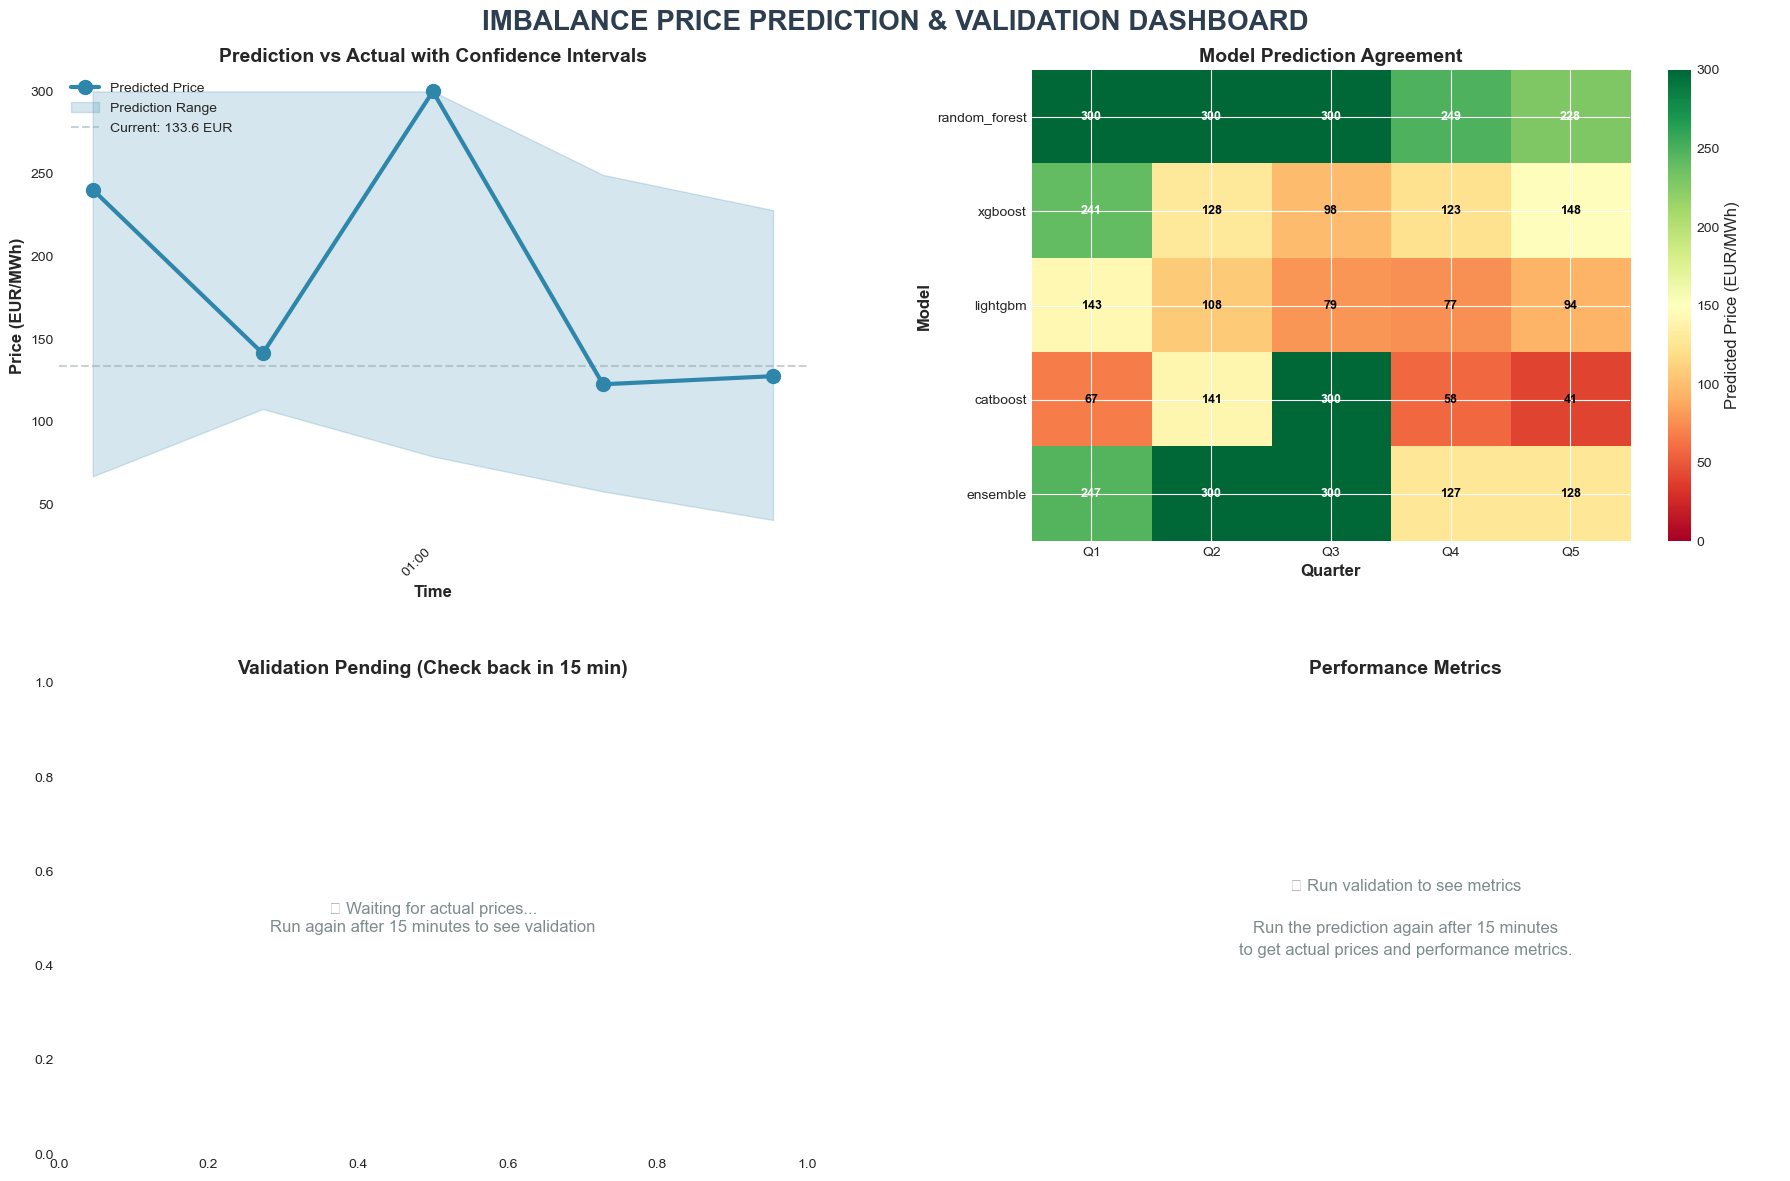


🔄 AUTO VALIDATION


Run automatic validation (wait 15 min)? (y/n):  y



🔄 AUTOMATIC VALIDATION CYCLE

📡 Step 1: Making prediction...
✅ Created 116 numeric features
   X shape: (198, 116)
   Targets: ['p1', 'p2', 'p3', 'p4', 'p5']
   Target times: 15, 30, 45, 60, 75 minutes ahead
   Predicted 5 future prices at: 01:00, 01:15, 01:30, 01:45, 02:00

📊 PREDICTION RESULTS
Current Time: 2026-08-15 00:57:53
Current Price: 133.97 EUR/MWh
Market Regime: Normal (Confidence: 75.7%)
Next Interval: 01:00
--------------------------------------------------------------------------------
Time         Quarter      Predicted    Range                Actual     Error     
--------------------------------------------------------------------------------
01:00        Q1           300.00       [148-300]            Pending    
01:15        Q2           251.22       [104-300]            Pending    
01:30        Q3           300.00       [82-300]             Pending    
01:45        Q4           113.73       [61-206]             Pending    
02:00        Q5           134.35       [50-

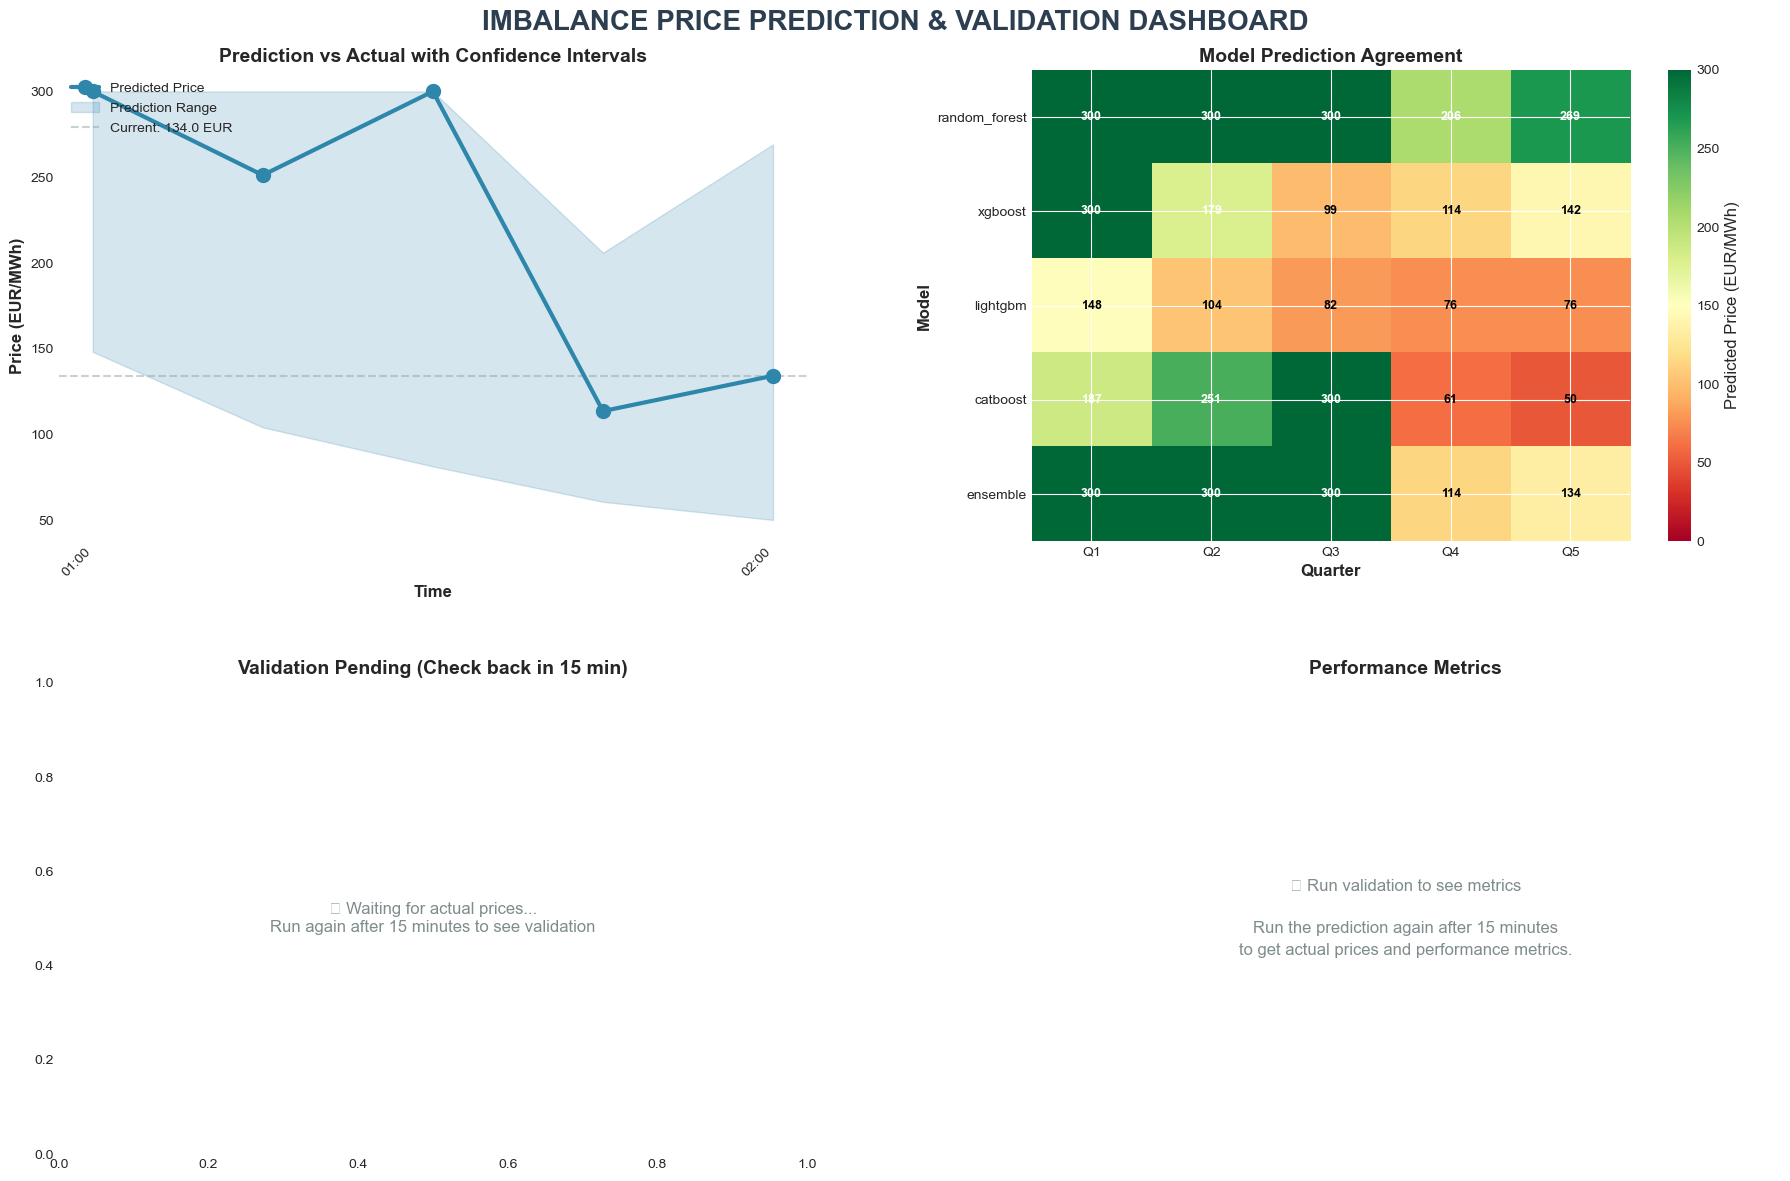

In [15]:
# ============================================
# COMPLETE CORRECTED PREDICTION SYSTEM
# ============================================

import pickle
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import requests
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Set professional style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['figure.titlesize'] = 16
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# ============================================
# PREDICTOR CLASS
# ============================================

class FuturePricePredictor:
    """
    Predict 5 future imbalance prices and validate against actual values
    """
    
    def __init__(self, model_path='models/DK1_model_5future.pkl'):
        self.model_path = model_path
        self.model_data = None
        self.prediction_history = []
        self.load_model()
    
    def load_model(self):
        """Load the trained model"""
        if not os.path.exists(self.model_path):
            raise FileNotFoundError(f"Model not found: {self.model_path}")
        
        with open(self.model_path, 'rb') as f:
            self.model_data = pickle.load(f)
        
        print(f"✅ Model loaded from {self.model_path}")
        print(f"   Training date: {self.model_data['train_date']}")
        print(f"   Features: {len(self.model_data['feature_columns'])}")
        print(f"   Price Area: {self.model_data['price_area']}")
        print(f"   Predicting: {self.model_data['n_steps']} future prices")
        print(f"   Interval: {self.model_data['step_interval_minutes']} minutes")
    
    def get_next_interval_time(self, current_time=None):
        """Get the next 15-minute interval boundary"""
        if current_time is None:
            current_time = datetime.now()
        
        minutes = current_time.minute
        next_minutes = ((minutes // 15) + 1) * 15
        
        if next_minutes == 60:
            next_time = current_time.replace(minute=0, second=0, microsecond=0) + timedelta(hours=1)
        else:
            next_time = current_time.replace(minute=next_minutes, second=0, microsecond=0)
        
        return next_time
    
    def get_latest_data(self, hours_back=6, price_area='DK1'):
        """Fetch latest real data from API"""
        url = "https://api.energidataservice.dk/dataset/ImbalancePrice"
        
        end_date = datetime.now()
        start_date = end_date - timedelta(hours=hours_back)
        
        full_url = f"{url}?limit=500&timezone=Europe/Copenhagen&sort=TimeUTC+DESC&start={start_date.strftime('%Y-%m-%dT%H:%M:%S')}&end={end_date.strftime('%Y-%m-%dT%H:%M:%S')}&PriceArea={price_area}"
        
        try:
            response = requests.get(full_url, timeout=30)
            
            if response.status_code == 400:
                full_url = f"{url}?limit=200&timezone=Europe/Copenhagen&sort=TimeUTC+DESC&PriceArea={price_area}"
                response = requests.get(full_url, timeout=30)
            
            if response.status_code == 200:
                data = response.json()
                if data.get('records') and len(data['records']) > 0:
                    df = pd.DataFrame(data['records'])
                    
                    if 'TimeUTC' in df.columns:
                        df['timestamp'] = pd.to_datetime(df['TimeUTC'])
                    
                    for col in ['Imbalance Price (EUR)', 'ImbalancePriceEUR']:
                        if col in df.columns:
                            df['imbalance_price_eur'] = pd.to_numeric(df[col], errors='coerce')
                            break
                    
                    for col in ['Spot Price (EUR)', 'SpotPriceEUR']:
                        if col in df.columns:
                            df['spot_price_eur'] = pd.to_numeric(df[col], errors='coerce')
                            break
                    
                    for col in ['Satisfied Demand (MW)', 'SatisfiedDemand']:
                        if col in df.columns:
                            df['satisfied_demand'] = pd.to_numeric(df[col], errors='coerce')
                            break
                    
                    for col in ['Dominating Direction', 'DominatingDirection']:
                        if col in df.columns:
                            df['dominating_direction'] = pd.to_numeric(df[col], errors='coerce')
                            break
                    
                    df = df.dropna(subset=['imbalance_price_eur'])
                    
                    if len(df) > 0 and 'timestamp' in df.columns:
                        df = df.sort_values('timestamp')
                        return df
            
            return None
            
        except Exception as e:
            return None
    
    def get_actual_price_at_time(self, target_time, price_area='DK1'):
        """Fetch actual price at a specific time from API"""
        url = "https://api.energidataservice.dk/dataset/ImbalancePrice"
        
        start_time = target_time - timedelta(minutes=5)
        end_time = target_time + timedelta(minutes=5)
        
        full_url = f"{url}?limit=10&timezone=Europe/Copenhagen&sort=TimeUTC+ASC&start={start_time.strftime('%Y-%m-%dT%H:%M:%S')}&end={end_time.strftime('%Y-%m-%dT%H:%M:%S')}&PriceArea={price_area}"
        
        try:
            response = requests.get(full_url, timeout=30)
            if response.status_code == 200:
                data = response.json()
                if data.get('records') and len(data['records']) > 0:
                    df = pd.DataFrame(data['records'])
                    
                    for col in ['Imbalance Price (EUR)', 'ImbalancePriceEUR']:
                        if col in df.columns:
                            df['imbalance_price_eur'] = pd.to_numeric(df[col], errors='coerce')
                            break
                    
                    df = df.dropna(subset=['imbalance_price_eur'])
                    
                    if len(df) > 0:
                        # Find closest timestamp
                        if 'TimeUTC' in df.columns:
                            df['timestamp'] = pd.to_datetime(df['TimeUTC'])
                        df['time_diff'] = abs(df['timestamp'] - target_time)
                        closest = df.loc[df['time_diff'].idxmin()]
                        return closest['imbalance_price_eur']
            
            return None
        except:
            return None
    
    def predict_future_prices(self, use_live_data=True):
        """Predict 5 future prices at 15-minute intervals"""
        if self.model_data is None:
            raise ValueError("Model not loaded")
        
        # Get data
        df = self.get_latest_data(price_area=self.model_data['price_area'])
        
        if df is None or len(df) < 20:
            raise ValueError("Insufficient real data for prediction")
        
        # Prepare features
        preprocessor = self.model_data['preprocessor']
        X, _, _ = preprocessor.prepare_features(df, is_training=False)
        
        if len(X) == 0:
            raise ValueError("No features available")
        
        X_latest = X.iloc[-1:].copy()
        X_latest_np = X_latest.values.astype(float)
        
        # Ensure correct feature count
        expected_features = len(self.model_data['feature_columns'])
        if X_latest_np.shape[1] != expected_features:
            if X_latest_np.shape[1] < expected_features:
                pad = np.zeros((1, expected_features - X_latest_np.shape[1]))
                X_latest_np = np.hstack([X_latest_np, pad])
            else:
                X_latest_np = X_latest_np[:, :expected_features]
        
        # Get predictions
        future_prices = []
        individual_predictions = {}
        
        for step in range(1, self.model_data['n_steps'] + 1):
            step_key = f'p{step}'
            minutes_ahead = step * self.model_data['step_interval_minutes']
            step_models = self.model_data['models'].get(step_key, {})
            
            if not step_models:
                continue
            
            preds = []
            for name, model in step_models.items():
                try:
                    pred = float(model.predict(X_latest_np)[0])
                    pred = np.clip(pred, -50, 300)
                    preds.append(pred)
                    
                    if name not in individual_predictions:
                        individual_predictions[name] = []
                    individual_predictions[name].append(pred)
                except:
                    continue
            
            if preds:
                future_prices.append({
                    'step': step,
                    'minutes_ahead': minutes_ahead,
                    'price': np.median(preds),
                    'std': np.std(preds),
                    'min': np.min(preds),
                    'max': np.max(preds)
                })
        
        # Get regime
        regime_result = self.model_data['regime_classifier'].predict(X_latest_np, return_proba=True)
        
        current_price = df['imbalance_price_eur'].iloc[-1]
        current_time = datetime.now()
        next_interval = self.get_next_interval_time(current_time)
        future_times = [next_interval + timedelta(minutes=(i) * 15) for i in range(5)]
        
        # Try to get actual prices
        actual_prices = {}
        for i, future_time in enumerate(future_times):
            actual = self.get_actual_price_at_time(future_time, self.model_data['price_area'])
            if actual is not None:
                actual_prices[f'Q{i+1}'] = actual
        
        result = {
            'current_price': current_price,
            'current_time': current_time,
            'next_interval_time': next_interval,
            'regime': regime_result['regime_names'][0],
            'regime_confidence': float(regime_result['confidence'][0]),
            'future_prices': future_prices,
            'future_times': future_times,
            'individual_predictions': individual_predictions,
            'actual_prices': actual_prices,
            'validation_available': len(actual_prices) > 0
        }
        
        self.prediction_history.append(result)
        return result

# ============================================
# PRINT PREDICTION TABLE (FIXED)
# ============================================

def print_prediction_table(result):
    """
    Print predictions in a clean table format
    """
    if result is None:
        print("❌ No results to display")
        return
    
    print("\n" + "="*80)
    print("📊 PREDICTION RESULTS")
    print("="*80)
    print(f"Current Time: {result['current_time'].strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Current Price: {result['current_price']:.2f} EUR/MWh")
    print(f"Market Regime: {result['regime']} (Confidence: {result['regime_confidence']:.1%})")
    print(f"Next Interval: {result['next_interval_time'].strftime('%H:%M')}")
    print("-"*80)
    print(f"{'Time':<12} {'Quarter':<12} {'Predicted':<12} {'Range':<20} {'Actual':<10} {'Error':<10}")
    print("-"*80)
    
    for i, (price_info, future_time) in enumerate(zip(result['future_prices'], result['future_times']), 1):
        time_str = future_time.strftime('%H:%M')
        q_label = f"Q{i}"
        
        # Get actual if available
        actual = result.get('actual_prices', {}).get(f'Q{i}')
        actual_str = f"{actual:.2f}" if actual else "Pending"
        
        # Calculate error
        error_str = ""
        if actual:
            error = abs(price_info['price'] - actual)
            status = "✅" if error < 20 else "⚠️" if error < 50 else "❌"
            error_str = f"{status} {error:.1f}"
        
        # FIXED: Properly format the print statement
        range_str = f"[{price_info['min']:.0f}-{price_info['max']:.0f}]"
        print(f"{time_str:<12} {q_label:<12} {price_info['price']:<12.2f} {range_str:<20} {actual_str:<10} {error_str}")
    
    print("-"*80)
    
    # Summary
    prices = [p['price'] for p in result['future_prices']]
    avg_price = np.mean(prices)
    trend = "📈 Up" if prices[-1] > prices[0] else "📉 Down"
    
    print(f"Summary: Avg: {avg_price:.2f} | Trend: {trend} | Regime: {result['regime']}")
    print("="*80)

# ============================================
# PROFESSIONAL DASHBOARD
# ============================================

def create_professional_dashboard(result, save_path=None):
    """
    Create a professional dashboard with 4 panels
    """
    if result is None:
        print("❌ No results to display")
        return
    
    fig = plt.figure(figsize=(18, 12))
    fig.suptitle('IMBALANCE PRICE PREDICTION & VALIDATION DASHBOARD', 
                 fontsize=20, fontweight='bold', color='#2C3E50', y=0.98)
    
    # ============================================
    # Panel 1: Prediction vs Actual (Top Left)
    # ============================================
    ax1 = plt.subplot(2, 2, 1)
    
    future_times = result['future_times']
    predicted_prices = [p['price'] for p in result['future_prices']]
    lower_bounds = [p['min'] for p in result['future_prices']]
    upper_bounds = [p['max'] for p in result['future_prices']]
    
    # Get actual prices
    actual_prices = []
    actual_times = []
    for i, q in enumerate(['Q1', 'Q2', 'Q3', 'Q4', 'Q5']):
        if q in result.get('actual_prices', {}):
            actual_prices.append(result['actual_prices'][q])
            actual_times.append(future_times[i])
    
    # Plot prediction line
    ax1.plot(future_times, predicted_prices, 'o-', color='#2E86AB', 
            linewidth=3, markersize=10, label='Predicted Price', zorder=3)
    
    # Add confidence intervals
    ax1.fill_between(future_times, lower_bounds, upper_bounds, 
                     color='#2E86AB', alpha=0.2, label='Prediction Range')
    
    # Add actual prices if available
    if actual_prices:
        ax1.scatter(actual_times, actual_prices, color='#E74C3C', 
                   s=200, zorder=4, label='Actual Price', 
                   marker='s', edgecolor='black', linewidth=2)
        
        # Connect actual to prediction with error lines
        for i, (t, actual) in enumerate(zip(actual_times, actual_prices)):
            pred = predicted_prices[i] if i < len(predicted_prices) else 0
            error = abs(actual - pred)
            color = '#27AE60' if error < 20 else '#F39C12' if error < 50 else '#E74C3C'
            ax1.plot([t, t], [min(actual, pred), max(actual, pred)], 
                    color=color, alpha=0.7, linewidth=2)
            ax1.text(t, pred + 3, f'Err: {error:.1f}', 
                    ha='center', va='bottom', fontsize=9, color='#2C3E50')
    
    # Add current price reference
    ax1.axhline(y=result['current_price'], color='#95A5A6', linestyle='--', 
               alpha=0.5, label=f'Current: {result["current_price"]:.1f} EUR')
    
    # Formatting
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax1.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax1.set_xlabel('Time', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Price (EUR/MWh)', fontsize=12, fontweight='bold')
    ax1.set_title('Prediction vs Actual with Confidence Intervals', fontsize=14, fontweight='bold')
    ax1.legend(loc='upper left', fontsize=10)
    ax1.grid(True, alpha=0.3)
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # ============================================
    # Panel 2: Model Agreement Heatmap (Top Right)
    # ============================================
    ax2 = plt.subplot(2, 2, 2)
    
    individual_preds = result.get('individual_predictions', {})
    if individual_preds:
        models = list(individual_preds.keys())
        quarters = [f'Q{i+1}' for i in range(len(result['future_prices']))]
        
        # Create data matrix
        data = []
        for model in models:
            data.append(individual_preds[model])
        
        # Create heatmap
        im = ax2.imshow(data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=300)
        ax2.set_xticks(range(len(quarters)))
        ax2.set_yticks(range(len(models)))
        ax2.set_xticklabels(quarters, fontsize=10)
        ax2.set_yticklabels(models, fontsize=10)
        ax2.set_xlabel('Quarter', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Model', fontsize=12, fontweight='bold')
        ax2.set_title('Model Prediction Agreement', fontsize=14, fontweight='bold')
        
        # Add colorbar
        cbar = plt.colorbar(im, ax=ax2, label='Predicted Price (EUR/MWh)')
        cbar.ax.tick_params(labelsize=10)
        
        # Add text annotations
        for i in range(len(models)):
            for j in range(len(quarters)):
                val = data[i][j] if j < len(data[i]) else 0
                color = 'white' if val > 150 else 'black'
                ax2.text(j, i, f'{val:.0f}', ha="center", va="center", 
                        color=color, fontsize=9, fontweight='bold')
    
    # ============================================
    # Panel 3: Error Analysis (Bottom Left)
    # ============================================
    ax3 = plt.subplot(2, 2, 3)
    
    if result.get('validation_available', False):
        actual_prices = result.get('actual_prices', {})
        errors = []
        q_names = []
        
        for i, q in enumerate(['Q1', 'Q2', 'Q3', 'Q4', 'Q5']):
            if q in actual_prices:
                pred = result['future_prices'][i]['price']
                actual = actual_prices[q]
                errors.append(abs(pred - actual))
                q_names.append(q)
        
        if errors:
            colors = ['#27AE60' if e < 20 else '#F39C12' if e < 50 else '#E74C3C' for e in errors]
            bars = ax3.bar(q_names, errors, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
            
            # Add value labels
            for bar, err in zip(bars, errors):
                height = bar.get_height()
                ax3.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                        f'{err:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
            
            ax3.set_xlabel('Quarter', fontsize=12, fontweight='bold')
            ax3.set_ylabel('Absolute Error (EUR/MWh)', fontsize=12, fontweight='bold')
            ax3.set_title('Prediction Accuracy by Quarter', fontsize=14, fontweight='bold')
            ax3.grid(True, alpha=0.3, axis='y')
            
            # Add threshold lines
            ax3.axhline(y=20, color='#27AE60', linestyle='--', alpha=0.5, linewidth=2, label='Good (20 EUR)')
            ax3.axhline(y=50, color='#F39C12', linestyle='--', alpha=0.5, linewidth=2, label='Acceptable (50 EUR)')
            ax3.legend(loc='upper left', fontsize=10)
            ax3.set_ylim(0, max(errors) * 1.3 if errors else 100)
    else:
        ax3.text(0.5, 0.5, '⏳ Waiting for actual prices...\nRun again after 15 minutes to see validation',
                ha='center', va='center', transform=ax3.transAxes, fontsize=12, color='#7F8C8D')
        ax3.set_title('Validation Pending (Check back in 15 min)', fontsize=14, fontweight='bold')
    
    # ============================================
    # Panel 4: Performance Metrics (Bottom Right)
    # ============================================
    ax4 = plt.subplot(2, 2, 4)
    ax4.axis('off')
    
    # Calculate metrics if validation available
    if result.get('validation_available', False):
        actual_prices = result.get('actual_prices', {})
        errors = []
        percentage_errors = []
        
        for i, q in enumerate(['Q1', 'Q2', 'Q3', 'Q4', 'Q5']):
            if q in actual_prices:
                pred = result['future_prices'][i]['price']
                actual = actual_prices[q]
                errors.append(abs(pred - actual))
                percentage_errors.append(abs(pred - actual) / (actual + 0.01) * 100)
        
        if errors:
            mae = np.mean(errors)
            rmse = np.sqrt(np.mean(np.array(errors)**2))
            mape = np.mean(percentage_errors)
            max_error = np.max(errors)
            accuracy_rate = sum(1 for e in errors if e < 20) / len(errors) * 100
            
            # Create professional metrics card
            metrics_text = f"""
╔══════════════════════════════════════════════════════════════╗
║                    PERFORMANCE METRICS                       ║
╠══════════════════════════════════════════════════════════════╣
║  📊 MAE (Mean Absolute Error):        {mae:>8.2f} EUR/MWh  ║
║  📊 RMSE (Root Mean Square Error):    {rmse:>8.2f} EUR/MWh  ║
║  📊 MAPE (Mean Absolute % Error):     {mape:>8.1f}%         ║
║  📊 Max Error:                        {max_error:>8.2f} EUR/MWh  ║
║  📊 Accuracy (<20 EUR):               {accuracy_rate:>8.0f}%       ║
║  📊 Validated Predictions:            {len(errors):>8d}/5     ║
╚══════════════════════════════════════════════════════════════╝

📈 Model Performance Summary:
• {'✅ Excellent' if mae < 20 else '⚠️ Good' if mae < 50 else '❌ Needs Improvement'}
• {'✅ High Confidence' if accuracy_rate > 80 else '⚠️ Moderate Confidence' if accuracy_rate > 50 else '❌ Low Confidence'}
            """
            
            ax4.text(0.05, 0.95, metrics_text, transform=ax4.transAxes, 
                    fontsize=11, verticalalignment='top', fontfamily='monospace',
                    bbox=dict(boxstyle='round', facecolor='#F8F9FA', 
                             edgecolor='#2C3E50', linewidth=2, pad=15))
    else:
        ax4.text(0.5, 0.5, '⏳ Run validation to see metrics\n\nRun the prediction again after 15 minutes\nto get actual prices and performance metrics.',
                ha='center', va='center', transform=ax4.transAxes, 
                fontsize=12, color='#7F8C8D', linespacing=1.5)
        ax4.set_title('Performance Metrics', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.93, hspace=0.3, wspace=0.3)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✅ Dashboard saved to {save_path}")
    
    plt.show()
    return fig

# ============================================
# AUTO VALIDATION FUNCTION
# ============================================

def run_auto_validation(predictor, wait_minutes=15):
    """
    Run automatic validation: predict, wait, validate
    """
    print("\n" + "="*80)
    print("🔄 AUTOMATIC VALIDATION CYCLE")
    print("="*80)
    
    # Step 1: Make prediction
    print("\n📡 Step 1: Making prediction...")
    result = predictor.predict_future_prices()
    
    if not result:
        print("❌ Failed to make prediction")
        return None
    
    print(f"   Predicted 5 future prices at: {', '.join([t.strftime('%H:%M') for t in result['future_times']])}")
    print_prediction_table(result)
    
    # Step 2: Wait
    print(f"\n⏳ Step 2: Waiting {wait_minutes} minutes for actual data...")
    print("   (You can skip waiting by pressing Ctrl+C)")
    try:
        import time
        for i in range(wait_minutes):
            time.sleep(60)
            if i % 5 == 0:
                print(f"   ... waited {i+1} minutes")
    except KeyboardInterrupt:
        print("\n   ⏹️ Wait interrupted by user")
        return result
    
    # Step 3: Get actual prices
    print("\n📡 Step 3: Fetching actual prices...")
    actual_prices = {}
    for i, future_time in enumerate(result['future_times']):
        actual = predictor.get_actual_price_at_time(future_time, predictor.model_data['price_area'])
        if actual is not None:
            actual_prices[f'Q{i+1}'] = actual
            print(f"   Q{i+1} ({future_time.strftime('%H:%M')}): {actual:.2f} EUR/MWh")
        else:
            print(f"   Q{i+1} ({future_time.strftime('%H:%M')}): Not available")
    
    # Step 4: Update result
    result['actual_prices'] = actual_prices
    result['validation_available'] = len(actual_prices) > 0
    predictor.prediction_history.append(result)
    
    # Step 5: Show final results
    print("\n📊 Step 4: Validation Results")
    print("="*80)
    print_prediction_table(result)
    
    # Step 6: Create dashboard
    print("\n📊 Step 5: Creating Dashboard...")
    create_professional_dashboard(result, save_path='validation_dashboard.png')
    
    return result

# ============================================
# MAIN EXECUTION
# ============================================

def run_complete_system():
    """
    Run the complete prediction and validation system
    """
    print("="*80)
    print("📊 IMBALANCE PRICE PREDICTION & VALIDATION SYSTEM")
    print("   Commercial-Grade Dashboard with Real-Time Validation")
    print("="*80)
    
    # Load predictor
    print("\n🔧 Loading model...")
    try:
        predictor = FuturePricePredictor('models/DK1_model_5future.pkl')
    except FileNotFoundError:
        print("❌ Model not found! Please train the model first.")
        print("   Run the training code before using this system.")
        return
    
    print("\n" + "="*80)
    print("📋 AVAILABLE FUNCTIONS")
    print("="*80)
    print("""
1. Quick Prediction (No wait):
   result = predictor.predict_future_prices()
   print_prediction_table(result)
   create_professional_dashboard(result)

2. Auto Validation (Waits 15 min):
   result = run_auto_validation(predictor, wait_minutes=15)

3. Check Previous Results:
   # Access history
   for r in predictor.prediction_history:
       print_prediction_table(r)
    """)
    
    # Run quick prediction
    print("\n" + "="*80)
    print("📊 RUNNING QUICK PREDICTION...")
    print("="*80)
    
    result = predictor.predict_future_prices()
    if result:
        print_prediction_table(result)
        create_professional_dashboard(result, save_path='prediction_dashboard.png')
    
    # Ask for auto validation
    print("\n" + "="*80)
    print("🔄 AUTO VALIDATION")
    print("="*80)
    auto = input("Run automatic validation (wait 15 min)? (y/n): ")
    if auto.lower() == 'y':
        #run_auto_validation(predictor, wait_minutes=15)
        # Wait 30 minutes and run validation again
        # This will have actual data for the first 2-3 quarters
        import time
        time.sleep(1800)  # Wait 30 minutes

        # Then re-run validation
        result = run_auto_validation(predictor, wait_minutes=0)  # No wait needed
    return predictor

# ============================================
# RUN THE SYSTEM
# ============================================

if __name__ == "__main__":
    predictor = run_complete_system()